In [1]:
# --- Step 1: Upload ZIP ---
from google.colab import files
uploaded = files.upload()   # Upload CNN.zip

# --- Step 2: Unzip ---
import zipfile, os

with zipfile.ZipFile("CNN.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/")

base_dir = "/content/CNN"
print("Base directory:", base_dir)

Saving CNN.zip to CNN.zip
Base directory: /content/CNN


In [2]:
# --- Step 3: Imports ---
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report


In [3]:
from PIL import Image
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# --- Step 0: Convert all images to RGB to avoid warnings ---
def convert_to_rgb(folder):
    for subdir, _, files in os.walk(folder):
        for file in files:
            filepath = os.path.join(subdir, file)
            try:
                img = Image.open(filepath)
                if img.mode != 'RGB':
                    img = img.convert('RGB')
                    img.save(filepath)
            except Exception as e:
                print(f"Error processing {filepath}: {e}")

convert_to_rgb(f"{base_dir}/Train")
convert_to_rgb(f"{base_dir}/Val")
convert_to_rgb(f"{base_dir}/Test")

# --- Step 4: Dataset setup ---
train_dir = f"{base_dir}/Train"
val_dir   = f"{base_dir}/Val"
test_dir  = f"{base_dir}/Test"

# --- Data augmentation ---
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.7, 1.3],
    channel_shift_range=20.0,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

img_size = (224, 224)
batch_size = 16

train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=img_size, batch_size=batch_size, class_mode="categorical"
)

val_generator = val_datagen.flow_from_directory(
    val_dir, target_size=img_size, batch_size=batch_size, class_mode="categorical"
)

test_generator = test_datagen.flow_from_directory(
    test_dir, target_size=img_size, batch_size=batch_size, class_mode="categorical", shuffle=False
)


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Found 270 images belonging to 6 classes.
Found 90 images belonging to 6 classes.
Found 90 images belonging to 6 classes.


In [4]:
# --- Step 5: Model ---
base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(224,224,3))
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
predictions = Dense(train_generator.num_classes, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=predictions)

# Freeze base for initial training
for layer in base_model.layers:
    layer.trainable = False

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.2084 - loss: 2.2083 - val_accuracy: 0.2333 - val_loss: 1.6949
Epoch 2/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.3384 - loss: 1.7009 - val_accuracy: 0.4222 - val_loss: 1.3724
Epoch 3/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.4983 - loss: 1.2820 - val_accuracy: 0.5000 - val_loss: 1.1662
Epoch 4/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.5339 - loss: 1.1827 - val_accuracy: 0.6000 - val_loss: 1.0208
Epoch 5/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.6323 - loss: 0.9868 - val_accuracy: 0.6111 - val_loss: 0.9522
Epoch 6/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.7473 - loss: 0.7947 - val_accuracy: 0.6556 - val_loss: 0.8795
Epoch 7/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.7885 - loss: 0.7045 - val_accuracy: 0.6778 - val_loss: 0.8873
Epoch 8/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.7341 - loss: 0.7697 - val_accuracy: 0.7000 - val_loss:

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,265,670 (8.64 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 10/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.8120 - loss: 0.5789 - val_accuracy: 0.7000 - val_loss: 0.7654
Epoch 11/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.7964 - loss: 0.6102 - val_accuracy: 0.7000 - val_loss: 0.7649
Epoch 12/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.8002 - loss: 0.6188 - val_accuracy: 0.7111 - val_loss: 0.7648
Epoch 13/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.7483 - loss: 0.6952 - val_accuracy: 0.7111 - val_loss: 0.7650
Epoch 14/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.8254 - loss: 0.5994 - val_accuracy: 0.7111 - val_loss: 0.7649
Epoch 15/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.7802 - loss: 0.6214 - val_accuracy: 0.7000 - val_loss: 0.7648
Epoch 16/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.7646 - loss: 0.6805 - val_accuracy: 0.7111 - val_loss: 0.7650
Epoch 17/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.7794 - loss: 0.5983 - val_accuracy: 0.7111 - v

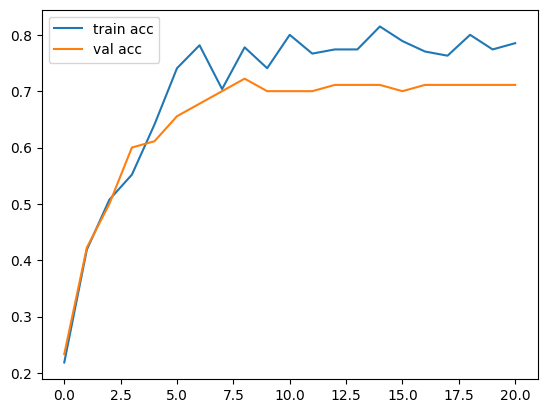

In [5]:



# --- Step 6: Train ---
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)
# --- Step 6b: Fine-Tuning ---
# This is the crucial second step to improve performance.

print("\n--- Starting Fine-Tuning ---")

# Unfreeze the base model to allow its weights to be updated
base_model.trainable = True

# We will only fine-tune the top layers. Let's see how many layers are in the model.
print(f"Number of layers in the base model: {len(base_model.layers)}")

# Let's freeze all layers before the 100th layer
fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Re-compile the model with a very low learning rate. This is CRITICAL.
model.compile(
    loss='categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), # Use a very low learning rate
    metrics=['accuracy']
)

model.summary() # See which layers are trainable now

# Continue training the model (fine-tuning)
fine_tune_epochs = 10
total_epochs = 10 + fine_tune_epochs

history_fine_tune = model.fit(
    train_generator,
    epochs=total_epochs,
    initial_epoch=history.epoch[-1], # Start from where we left off
    validation_data=val_generator
)

# Append the fine-tuning history to the original history
history.history['accuracy'].extend(history_fine_tune.history['accuracy'])
history.history['val_accuracy'].extend(history_fine_tune.history['val_accuracy'])
history.history['loss'].extend(history_fine_tune.history['loss'])
history.history['val_loss'].extend(history_fine_tune.history['val_loss'])
# Plot training curve
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()


6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 974ms/step - accuracy: 0.7930 - loss: 0.6742
✅ Test Accuracy: 0.800000011920929
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 785ms/step


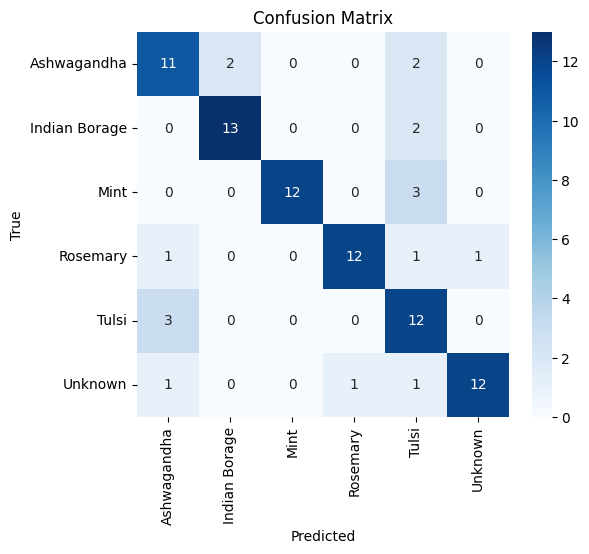

               precision    recall  f1-score   support

  Ashwagandha       0.69      0.73      0.71        15
Indian Borage       0.87      0.87      0.87        15
         Mint       1.00      0.80      0.89        15
     Rosemary       0.92      0.80      0.86        15
        Tulsi       0.57      0.80      0.67        15
      Unknown       0.92      0.80      0.86        15

     accuracy                           0.80        90
    macro avg       0.83      0.80      0.81        90
 weighted avg       0.83      0.80      0.81        90



In [6]:
# --- Step 7: Evaluate ---
test_loss, test_acc = model.evaluate(test_generator)
print("✅ Test Accuracy:", test_acc)

# Confusion matrix
Y_pred = model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1)

cm = confusion_matrix(test_generator.classes, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=list(train_generator.class_indices.keys()),
            yticklabels=list(train_generator.class_indices.keys()))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(test_generator.classes, y_pred,
                            target_names=list(train_generator.class_indices.keys())))
